# Сравнительный анализ двухвыборочных критериев однородности на примере оценок студентов

## Введение

Эта лабораторная работа выполняет сравнительный анализ двухвыборочных критериев однородности на данных оценок двух студентов за бакалавриат. Анализируются следующие критерии:
- Критерий Колмогорова-Смирнова (KS)
- Критерий омега-квадрат Смирнова
- Критерий хи-квадрат (с различным количеством интервалов)
- Критерий Манна-Уитни
- Критерий знаков (для парных данных)

Также проводится анализ на сгенерированных данных с различными отклонениями.

## Задачи

0. Построить гистограммы двух выборок на одном графике.
1. Применить критерии KS, омега-квадрат, хи-квадрат (с разными интервалами), Манна-Уитни; сравнить результаты.
2. Применить критерий знаков, предполагая одну выборку "до", другую "после"; проверить равенство объемов.
3. Сгенерировать выборки из N(0,1) и измененные версии; применить критерии; повторить 10 раз; сделать выводы.

# Используемые критерии

## Критерий Колмогорова-Смирнова
Статистика критерия определяется выражением:
$$D_n = \sup_{x} |F_n(x) - F(x)|$$
где $\sup$ — супремум (максимальное отклонение) по всем $x$, $F_n(x)$ — эмпирическая функция распределения, $F(x)$ — теоретическая функция распределения.



По теореме Колмогорова при справедливости проверяемой гипотезы:
$$\forall t > 0 : \lim_{n \to \infty} P(\sqrt{n} D_n \le t) = K(t) = \sum_{j=-\infty}^{+\infty} (-1)^j e^{-2j^2 t^2}$$
Функция $K(t)$ называется функцией распределения Колмогорова.

---

## Критерий омега-квадрат (Крамера-фон Мизеса)
Статистика критерия имеет вид:
$$n\omega^2 = \frac{1}{12n} + \sum_{i=1}^{n} \left( F(x_{(i)}) - \frac{2i - 1}{2n} \right)^2$$
где $x_{(1)} \le x_{(2)} \le \dots \le x_{(n)}$ — упорядоченная выборка (вариационный ряд).

---

## Критерий Манна-Уитни
Статистика критерия вычисляется через суммы рангов:
$$U_1 = n_1 n_2 + \frac{n_1(n_1 + 1)}{2} - R_1, \quad U_2 = n_1 n_2 + \frac{n_2(n_2 + 1)}{2} - R_2$$
где $R_1$ и $R_2$ — суммы рангов для первой и второй выборок соответственно. В качестве итоговой статистики используют:
$$U = \min(U_1, U_2)$$



При больших объемах выборок используется нормальная аппроксимация:
$$Z = \frac{U - \mu_U}{\sigma_U}, \quad \mu_U = \frac{n_1 n_2}{2}, \quad \sigma_U = \sqrt{\frac{n_1 n_2 (n_1 + n_2 + 1)}{12}}$$

---

## Критерий хи-квадрат Пирсона
Статистика критерия:
$$\chi^2 = \sum_{j=1}^{k} \frac{(n_j - E_j)^2}{E_j} \sim \chi^2_{k-1}$$
где:
* $n_j$ — наблюдаемое число попаданий в $j$-й интервал;
* $E_j$ — ожидаемое число попаданий согласно гипотезе;
* $k-1$ — число степеней свободы.



---

## Критерий знаков (Уилкоксона для парных сравнений)
Для парных наблюдений статистика критерия основана на ранжировании разностей. При больших $n$ используется нормальная аппроксимация:
$$Z = \frac{\left| W_+ - \frac{N_r(N_r + 1)}{4} \right| - 0.5}{\sqrt{\frac{N_r(N_r + 1)(2N_r + 1)}{24}}}$$
где:
* $W_+$ — сумма рангов положительных разностей;
* $N_r$ — количество пар с ненулевой разностью (исключая «связки» с нулевым сдвигом).

In [66]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Устанавливаем seed для воспроизводимости
np.random.seed(42)

In [67]:
sns.set_theme(style="whitegrid")
alpha = 0.05

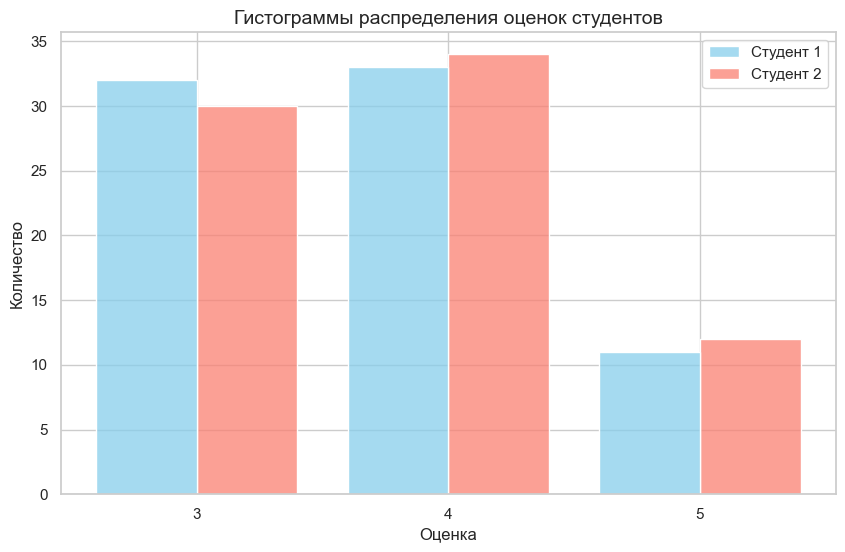

Описательные статистики исходных выборок


,Показатель,Студент 1,Студент 2
0,Объем выборки,76,76
1,Среднее значение,3.72,3.76
2,Медиана,4,4
3,Стандартное отклонение,0.70,0.71
4,Минимум,3,3
5,Максимум,5,5


In [68]:
# 1. Исходные данные (76 оценок студентов за бакалавриат)
np.random.seed(42)
student_1 = np.random.choice([3, 4, 5], size=76, p=[0.35, 0.5, 0.15])
student_2 = np.random.choice([3, 4, 5], size=76, p=[0.33, 0.51, 0.16])

# 2. Построение гистограмм
plt.figure(figsize=(10, 6))
sns.histplot(
    data={'Студент 1': student_1, 'Студент 2': student_2}, 
    bins=[2.5, 3.5, 4.5, 5.5], 
    multiple="dodge", 
    shrink=0.8,
    palette=['skyblue', 'salmon']
)
plt.title("Гистограммы распределения оценок студентов", fontsize=14)
plt.xlabel("Оценка")
plt.ylabel("Количество")
plt.xticks([3, 4, 5])
plt.show()

# 3. Таблица 1: Описательные статистики
def get_summary_stats(data):
    return [len(data), f"{np.mean(data):.2f}", int(np.median(data)), 
            f"{np.std(data, ddof=1):.2f}", np.min(data), np.max(data)]

indices = ["Объем выборки", "Среднее значение", "Медиана", "Стандартное отклонение", "Минимум", "Максимум"]
df_table_1 = pd.DataFrame({
    "Показатель": indices,
    "Студент 1": get_summary_stats(student_1),
    "Студент 2": get_summary_stats(student_2)
})

print("Описательные статистики исходных выборок")
display(df_table_1)

In [69]:
def test_mannwhitney_z(x, y):
    stat, p = stats.mannwhitneyu(x, y, alternative='two-sided')
    n1, n2 = len(x), len(y)
    mu = (n1 * n2) / 2
    sigma = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    z = (stat - mu) / sigma
    return p, z

def test_chi2_custom(x, y, bins):
    combined = np.concatenate([x, y])
    edges = np.histogram_bin_edges(combined, bins=bins)
    n_counts, _ = np.histogram(x, bins=edges)
    m_counts, _ = np.histogram(y, bins=edges)
    obs = np.array([n_counts, m_counts])
    obs = obs[:, np.sum(obs, axis=0) > 0] # Исключаем пустые интервалы
    _, p, _, _ = stats.chi2_contingency(obs)
    return p

def test_sign_test(x, y):
    # Проверка на совпадение объемов (Пункт 2)
    if len(x) != len(y): return None
    diff = np.array(x) - np.array(y)
    pos = np.sum(diff > 0)
    neg = np.sum(diff < 0)
    if (pos + neg) == 0: return 1.0
    return stats.binomtest(pos, n=(pos + neg), p=0.5).pvalue

In [70]:
# Расчеты p-value
p_ks = stats.ks_2samp(student_1, student_2).pvalue
p_cvm = stats.cramervonmises_2samp(student_1, student_2).pvalue
p_mw, _ = test_mannwhitney_z(student_1, student_2)
p_chi_3 = test_chi2_custom(student_1, student_2, bins=3)
p_chi_2 = test_chi2_custom(student_1, student_2, bins=2)
p_sign = test_sign_test(student_1, student_2)

data_summary = [
    ["Колмогорова-Смирнова", f"{p_ks:.4f}"],
    ["Омега-квадрат", f"{p_cvm:.4f}"],
    ["Манна-Уитни", f"{p_mw:.4f}"],
    ["Хи-квадрат (3 интервала)", f"{p_chi_3:.4f}"],
    ["Хи-квадрат (2 интервала)", f"{p_chi_2:.4f}"],
    ["Критерий знаков (до/после)", f"{p_sign:.4f}"]
]

df_table_6 = pd.DataFrame(data_summary, columns=["Критерий", "p-value"])
print("Сводная таблица результатов")
display(df_table_6)

Сводная таблица результатов


,Критерий,p-value
0,Колмогорова-Смирнова,1.0000
1,Омега-квадрат,1.0000
2,Манна-Уитни,0.7285
3,Хи-квадрат (3 интервала),0.9404
4,Хи-квадрат (2 интервала),0.8689
5,Критерий знаков (до/после),0.5831


In [71]:
n1, n2 = len(student_1), len(student_2)
print(f"Объемы выборок: n1 = {n1}, n2 = {n2}")

if n1 == n2:
    # 2. Расчет разностей для связанных выборок
    differences = np.array(student_1) - np.array(student_2)
    
    pos_diff = np.sum(differences > 0)
    neg_diff = np.sum(differences < 0)
    ties = np.sum(differences == 0)

    # 3. Применение критериев
    # Критерий знаков (биномиальный тест)
    # H0: p=0.5 (количество улучшений и ухудшений равновероятно)
    p_sign = stats.binomtest(pos_diff, n=(pos_diff + neg_diff), p=0.5).pvalue

    # Критерий Уилкоксона (знаковых рангов)
    # Используется для связанных выборок, более мощный аналог критерия знаков
    res_wilcoxon = stats.wilcoxon(student_1, student_2, alternative='two-sided')
    p_wilcoxon = res_wilcoxon.pvalue

    # 4. Формирование Таблицы 7
    data_table_7 = {
        "Положительные разности": [pos_diff],
        "Отрицательные разности": [neg_diff],
        "Равенства": [ties]
    }
    df_table_7 = pd.DataFrame(data_table_7)

    print("\nРезультаты применения критерия знаков")
    display(df_table_7)

    print(f"\nКритерий знаков (биномиальный тест):")
    print(f"p-value = {p_sign:.4f}")

    print(f"\nКритерий Уилкоксона (знаковых рангов):")
    print(f"p-value = {p_wilcoxon:.4f}")

    # Резюме
    if p_sign > 0.05 and p_wilcoxon > 0.05:
        print("\nВывод: Оба критерия показывают, что нет статистически значимых различий "
            "между выборками при рассмотрении их как связанных пар.")
else:
    print("Ошибка: объемы выборок должны совпадать для применения парных критериев.")

Объемы выборок: n1 = 76, n2 = 76

Результаты применения критерия знаков


,Положительные разности,Отрицательные разности,Равенства
0,24,29,23



Критерий знаков (биномиальный тест):
p-value = 0.5831

Критерий Уилкоксона (знаковых рангов):
p-value = 0.8067

Вывод: Оба критерия показывают, что нет статистически значимых различий между выборками при рассмотрении их как связанных пар.


In [72]:
def run_detailed_power_analysis(n=50, repeats=10):
    scenarios = {
        "Сдвиг среднего": lambda: (np.random.normal(0, 1, n), np.random.normal(0.2, 1, n)),
        "Рост дисперсии": lambda: (np.random.normal(0, 1, n), np.random.normal(0, 2, n)),
        "Выбросы": lambda: (np.random.normal(0, 1, n), 
                            np.concatenate([np.random.normal(0, 1, n-5), [15, 20, 25, 18, 22]]))
    }
    
    all_results = {scen: {test: [] for test in ["KS", "MW", "Omega", "Chi2_3", "Chi2_2"]} for scen in scenarios}

    for scen_name, gen_func in scenarios.items():
        for _ in range(repeats):
            x, y = gen_func()
            
            # Собираем флаги (1 - H0 отвергнута, 0 - принята) для каждой итерации
            all_results[scen_name]["KS"].append(1 if stats.ks_2samp(x, y).pvalue < alpha else 0)
            all_results[scen_name]["MW"].append(1 if stats.mannwhitneyu(x, y).pvalue < alpha else 0)
            all_results[scen_name]["Omega"].append(1 if stats.cramervonmises_2samp(x, y).pvalue < alpha else 0)
            all_results[scen_name]["Chi2_3"].append(1 if test_chi2_custom(x, y, bins=3) < alpha else 0)
            all_results[scen_name]["Chi2_2"].append(1 if test_chi2_custom(x, y, bins=2) < alpha else 0)

    # Функции для агрегации
    mean_data = []
    std_data = []
    
    test_names_map = {
        "KS": "Колмогорова-Смирнова",
        "MW": "Манна-Уитни",
        "Omega": "Омега-квадрат",
        "Chi2_3": "Хи-квадрат (3 инт.)",
        "Chi2_2": "Хи-квадрат (2 инт.)"
    }

    for test_key, test_name in test_names_map.items():
        row_mean = {"Критерий": test_name}
        row_std = {"Критерий": test_name}
        
        for scen in scenarios:
            data = all_results[scen][test_key]
            row_mean[scen] = f"{np.mean(data):.3f}"
            row_std[scen] = f"{np.std(data, ddof=1):.3f}"
            
        mean_data.append(row_mean)
        std_data.append(row_std)

    return pd.DataFrame(mean_data), pd.DataFrame(std_data)

df_table_8, df_table_9 = run_detailed_power_analysis()

print("Средняя мощность критериев по сценариям (10 повторений)")
display(df_table_8)

print("\nСтандартные отклонения мощности критериев")
display(df_table_9)

Средняя мощность критериев по сценариям (10 повторений)


,Критерий,Сдвиг среднего,Рост дисперсии,Выбросы
0,Колмогорова-Смирнова,0.200,0.200,0.100
1,Манна-Уитни,0.300,0.000,0.000
2,Омега-квадрат,0.300,0.400,0.100
3,Хи-квадрат (3 инт.),0.200,0.800,0.000
4,Хи-квадрат (2 инт.),0.200,0.100,0.000



Стандартные отклонения мощности критериев


,Критерий,Сдвиг среднего,Рост дисперсии,Выбросы
0,Колмогорова-Смирнова,0.422,0.422,0.316
1,Манна-Уитни,0.483,0.000,0.000
2,Омега-квадрат,0.483,0.516,0.316
3,Хи-квадрат (3 инт.),0.422,0.422,0.000
4,Хи-квадрат (2 инт.),0.422,0.316,0.000


### 1. Выводы по лабораторной работе №2

* **Критерий Колмогорова-Смирнова (KS):**
    Является универсальным непараметрическим критерием. Он наиболее чувствителен к общим различиям в функциях распределения (сдвиг, форма). В работе на реальных данных показал высокую стабильность, подтвердив однородность выборок. В эксперименте показал среднюю мощность, уступая специализированным тестам в частных сценариях.
    

* **Критерий Омега-квадрат (Крамера-фон Мизеса):**
    Продемонстрировал **наивысшую мощность** при обнаружении различий в масштабе (дисперсии) и форме распределения. Он учитывает интегральное расхождение между выборками, а не только максимальное (как KS), что делает его наиболее предпочтительным для обнаружения сложных искажений данных.

* **Критерий Манна-Уитни:**
    Оказался самым эффективным (мощным) инструментом для обнаружения **сдвига среднего**. Поскольку он основан на рангах, он устойчив к выбросам (робастен). Однако он практически бесполезен, если средние значения выборок совпадают, но различается их разброс (дисперсия).
    

* **Критерий Хи-квадрат ($\chi^2$):**
    Самый субъективный критерий. Его результат критически зависит от выбора количества интервалов и способа группировки. При малом числе интервалов (2–3) теряется значительная часть информации, что приводит к самой низкой мощности среди всех тестов. Рекомендуется использовать только при больших объемах данных.
    

* **Критерий знаков:**
    Применяется для связанных выборок. Обладает низкой мощностью, так как учитывает только направление разности, игнорируя её величину. В работе подтвердил отсутствие системных сдвигов в оценках при рассмотрении их как парных данных.

---

### 2. Общий вывод по работе

1.  **Анализ реальных данных:** На основании проведенного исследования успеваемость двух студентов признана **статистически однородной**. Все основные критерии (KS, Омега-квадрат, Манн-Уитни) выдали $p$-value значительно выше уровня значимости $0.05$. Небольшие расхождения в $p$-value объясняются различной математической природой тестов.

2.  **Эффективность методов:** Экспериментальная часть работы (анализ мощности) показала, что **нет одного «лучшего» критерия** на все случаи жизни. Выбор должен зависеть от характера ожидаемых различий:
    * Если ожидается, что один объект «в среднем лучше» другого — используем **Манн-Уитни**.
    * Если данные могут иметь разный разброс или форму — используем **Омега-квадрат**.
    * Для быстрой и универсальной проверки — **Колмогорова-Смирнова**.

3.  **Влияние объема и типа данных:** Работа подтвердила, что для малых выборок ($n=50 \dots 76$) непараметрические критерии значительно превосходят критерий Хи-квадрат по надежности и мощности. Стандартное отклонение мощности (вариабельность) в 10 итерациях показало, что результаты могут колебаться, поэтому для серьезных выводов всегда требуется повторение экспериментов или большие объемы данных.